# Laboratorio # 1

### Temas: Limpieza de Datos, análisis de negocio, integración de fuentes de datos, visualización datos

# 1. El problema del negocio

Una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término con el banco.

¿Qué perfil tienen los clientes con mayor potencial de conversión?

#2. El set de datos

La información recolectada por la empresa de mercadeo se encuentra en un archivo CSV (`dataset_banco.csv`) con 45215 filas y 17 columnas.

Cada registro contiene 16 características (las primeras 16 columnas) y una categoría ("yes" o "no" dependiendo de si la persona está o no interesada en adquirir el producto). Las columnas son:

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual de ingresos en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente)
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

#3. Una primera mirada al dataset

In [83]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt #libreria nos permite graficar
import seaborn as sns #libreria nos permite graficar estadistica


In [84]:
# Carga de datos con autorización de Drive (Opción 1)
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/dataset_banco.csv"

data = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
import os

In [86]:
# Definir la ruta de la carpeta en Google Drive
folder_path_destino = '/content/drive/MyDrive/Colab Notebooks/DA_Talento/data/'

In [87]:
# Verificar si la carpeta existe, si no, crearla
if not os.path.exists(folder_path_destino):
    os.makedirs(folder_path_destino)

# Guardar el archivo CSV en la carpeta
file_path = os.path.join(folder_path_destino, 'data_banco2.csv')
data.to_csv(file_path, index=False)

In [88]:
from google.colab import files
uploaded = files.upload()

In [89]:
#Carga de datos sin autorización de Drive (Opción 2)
data = pd.read_csv('/content/dataset_banco.csv')

In [90]:
data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,float64
housing,object
loan,object
contact,object
day,int64


In [91]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'poutcome', 'y'],
       dtype='object'))

In [92]:
for col in cat_cols:
    print(col)
    print(data[col].unique())
    print("-"*40)


job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'Management' 'retired' 'admin.' 'services' 'self-employed' 'MANAGEMENT'
 'Self-employed' 'unemployed' 'housemaid' 'student' 'Services' 'Retired'
 'administrative' nan]
----------------------------------------
marital
['married' 'single' 'div.' 'divorced' 'DIVORCED' 'Single' nan]
----------------------------------------
education
['tertiary' 'secondary' 'unknown' 'primary' 'SECONDARY' 'Secondary'
 'Primary' 'sec.' 'Tertiary' 'UNK' nan]
----------------------------------------
default
['no' 'yes']
----------------------------------------
housing
['yes' 'no']
----------------------------------------
loan
['no' 'yes' 'No' 'YES' 'Yes' 'NO']
----------------------------------------
contact
['unknown' 'cellular' 'telephone' 'phone' 'mobile']
----------------------------------------
month
['may' 'nov' 'jun' 'jul' 'aug' 'oct' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
----------------------------------------
poutcome
['unknown' 'U

In [93]:
data.isnull().sum()

,0
age,0
job,2
marital,1
education,1
default,0
balance,2
housing,0
loan,0
contact,0
day,0


<Axes: >

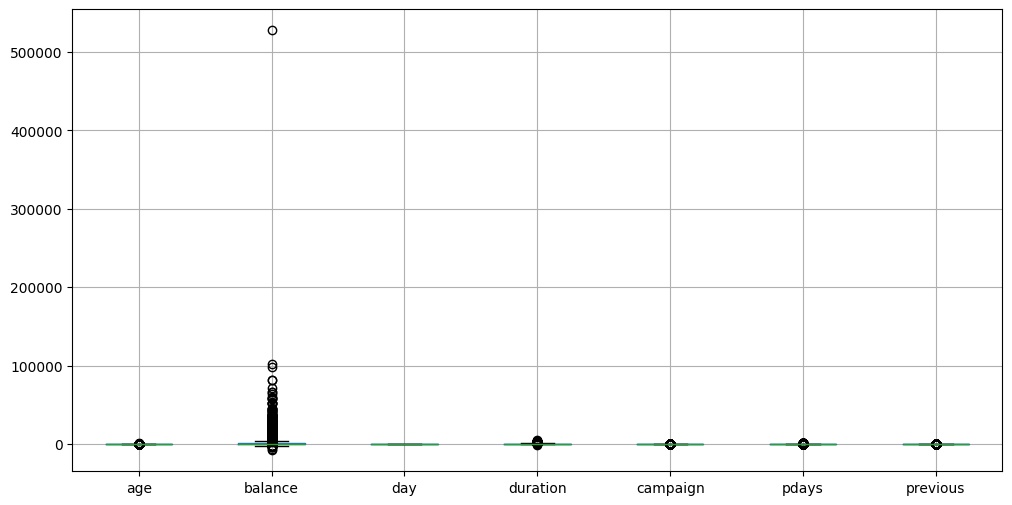

In [94]:
data[num_cols].boxplot(figsize=(12,6))


In [95]:
display(data)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


In [96]:
data.columns = data.columns.str.upper().str.replace(" ", "_")

In [97]:
display(data)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,BALANCE,HOUSING,LOAN,CONTACT,DAY,MONTH,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,Y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


## Función Limpieza

In [98]:
def clean_dataset(df):
    df = df.copy()

    df.columns = df.columns.str.lower().str.replace(" ", "_")

    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.lower().str.strip()

    return df


In [99]:
data = clean_dataset(data)

In [100]:
display(data)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


In [101]:
#validación de nombres sin transformación
print(data.shape)
data.head()

(45215, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [102]:
# Renombramos las columnas
data_rename_2 = data.rename(columns={
                                  'age':        'edad',
                                  'job':        'trabajo',
                                  'marital':    'estado_civil',
                                  'education':  'educacion',
                                  'default':    'morosidad',
                                  'balance':    'saldo',
                                  'housing':    'vivienda',
                                  'loan':       'prestamo',
                                  'contact':    'contacto',
                                  'day':        'dia',
                                  'month':      'mes',
                                  'duration':   'duracion',
                                  'campaign':   'campana',
                                  'pdays':      'dias_previos',
                                  'previous':   'anterior',
                                  'poutcome':   'resultado',
                                  'y':          'respuesta'})

# Verificamos los cambios
print(data_rename_2.head())

   edad       trabajo estado_civil  educacion morosidad   saldo vivienda  \
0    58    management      married   tertiary        no  2143.0      yes   
1    44    technician       single  secondary        no    29.0      yes   
2    33  entrepreneur      married  secondary        no     2.0      yes   
3    47   blue-collar      married    unknown        no  1506.0      yes   
4    33       unknown       single    unknown        no     1.0       no   

  prestamo contacto  dia  mes  duracion  campana  dias_previos  anterior  \
0       no  unknown    5  may     261.0        1          -1.0         0   
1       no  unknown    5  may     151.0        1          -1.0         0   
2      yes  unknown    5  may      76.0        1          -1.0         0   
3       no  unknown    5  may      92.0        1          -1.0         0   
4       no  unknown    5  may     198.0        1          -1.0         0   

  resultado respuesta  
0   unknown        no  
1   unknown        no  
2   unknown   

In [103]:
# Renombrar las columnas
data.columns = ['edad',
              'trabajo',
              'estado_civil',
              'educacion',
              'incumplimiento',
              'saldo',
              'vivienda',
              'prestamo',
              'contacto',
              'dia',
              'mes',
              'duracion',
              'campaña',
              'dias_previos',
              'anterior',
              'resultado_prev',
              'respuesta']

print(data.columns)

Index(['edad', 'trabajo', 'estado_civil', 'educacion', 'incumplimiento',
       'saldo', 'vivienda', 'prestamo', 'contacto', 'dia', 'mes', 'duracion',
       'campaña', 'dias_previos', 'anterior', 'resultado_prev', 'respuesta'],
      dtype='object')


In [104]:
print(data.shape)
data.head()

(45215, 17)


,edad,trabajo,estado_civil,educacion,incumplimiento,saldo,vivienda,prestamo,contacto,dia,mes,duracion,campaña,dias_previos,anterior,resultado_prev,respuesta
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [105]:
# Veamos las variables categóricas y las numéricas
data = data_rename_2
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   edad          45215 non-null  int64  
 1   trabajo       45213 non-null  object 
 2   estado_civil  45214 non-null  object 
 3   educacion     45214 non-null  object 
 4   morosidad     45215 non-null  object 
 5   saldo         45213 non-null  float64
 6   vivienda      45215 non-null  object 
 7   prestamo      45215 non-null  object 
 8   contacto      45215 non-null  object 
 9   dia           45215 non-null  int64  
 10  mes           45215 non-null  object 
 11  duracion      45214 non-null  float64
 12  campana       45215 non-null  int64  
 13  dias_previos  45214 non-null  float64
 14  anterior      45215 non-null  int64  
 15  resultado     45215 non-null  object 
 16  respuesta     45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


**categoricas = data.select_dtypes(include=['object']).columns.tolist()**

Este comando selecciona todas las columnas del DataFrame que tienen el **tipo de datos object**, lo cual usualmente indica **datos categóricos** o de **texto**. Luego, convierte los nombres de estas columnas en una **lista** y los almacena en la variable categoricas.


**numericas = data.select_dtypes(include=['int64', 'float64']).columns.tolist()**

Este comando selecciona todas las columnas del DataFrame que tienen tipos de datos numéricos (**int64** para enteros y **float64** para números decimales). Convierte los nombres de estas columnas en una lista y los almacena en la variable numericas.

In [106]:
# Clasificar columnas
categoricas = data.select_dtypes(include=['object']).columns.tolist()
numericas = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas categóricas:", categoricas)
print("Columnas numéricas:", numericas)

Columnas categóricas: ['trabajo', 'estado_civil', 'educacion', 'morosidad', 'vivienda', 'prestamo', 'contacto', 'mes', 'resultado', 'respuesta']
Columnas numéricas: ['edad', 'saldo', 'dia', 'duracion', 'campana', 'dias_previos', 'anterior']


In [107]:
pd.value_counts(data['educacion'])

/tmp/ipykernel_1439/1773724929.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data['educacion'])


,count
educacion,
secondary,23201
tertiary,13303
primary,6851
unknown,1855
sec.,2
unk,2


In [108]:
#cambia los nombres de las columnas del dataframe
#visualiza las primeras líneas de tu .csv
#visualiza las variables categóricas y las numéricas
#proporciona estadísticas descriptivas para columnas numéricas

In [110]:
#cambia los nombres de las columnas del dataframe

data.columns = ['edad',
              'trabajo',
              'estado_civil',
              'educacion',
              'incumplimiento',
              'saldo',
              'vivienda',
              'prestamo',
              'contacto',
              'dia',
              'mes',
              'duracion',
              'campaña',
              'dias_previos',
              'anterior',
              'resultado_prev',
              'respuesta']

print(data.columns)


Index(['edad', 'trabajo', 'estado_civil', 'educacion', 'incumplimiento',
       'saldo', 'vivienda', 'prestamo', 'contacto', 'dia', 'mes', 'duracion',
       'campaña', 'dias_previos', 'anterior', 'resultado_prev', 'respuesta'],
      dtype='object')


In [109]:
#visualiza las primeras líneas de tu .csv

print(data.shape)
data.head()

(45215, 17)


,edad,trabajo,estado_civil,educacion,morosidad,saldo,vivienda,prestamo,contacto,dia,mes,duracion,campana,dias_previos,anterior,resultado,respuesta
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [111]:
#visualiza las variables categóricas y las numéricas

categoricas = data.select_dtypes(include=['object']).columns.tolist()
numericas = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas categóricas:", categoricas)
print("Columnas numéricas:", numericas)

Columnas categóricas: ['trabajo', 'estado_civil', 'educacion', 'incumplimiento', 'vivienda', 'prestamo', 'contacto', 'mes', 'resultado_prev', 'respuesta']
Columnas numéricas: ['edad', 'saldo', 'dia', 'duracion', 'campaña', 'dias_previos', 'anterior']


In [112]:
#proporciona estadísticas descriptivas para columnas numéricas

data.describe()

,edad,saldo,dia,duracion,campaña,dias_previos,anterior
count,45215.000000,45213.000000,45215.000000,45214.000000,45215.000000,45214.000000,45215.000000
mean,41.004711,1374.159866,15.805839,258.074357,2.763729,40.192485,0.580383
std,12.036647,3924.255525,8.322473,257.605175,3.097910,100.120622,2.303438
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#4. Limpieza

Realizaremos el proceso de limpieza teniendo en cuenta las situaciones más comunes:

1. Datos faltantes en algunas celdas
2. Columnas irrelevantes (que no responden al problema que queremos resolver)
3. Registros (filas) repetidos
4. Valores extremos (*outliers*) en el caso de las variables numéricas. Se deben analizar en detalle pues no necesariamente la solución es eliminarlos
5. Errores tipográficos en el caso de las variables categóricas

Al final de este proceso de limpieza deberíamos tener un set de datos **íntegro**, listo para la fase de Análisis Exploratorio.

## 4.1 Datos faltantes

Acá comenzamos a ver que los datos no están completos, pues no todas las columnas tienen la misma cantidad de registros.

El número total de registros debería ser 45.215. Sin embargo columnas como "job", "marital", "education", "balance", "duration" y "pdays".

Por ser tan pocos los datos  faltantes optaremos por eliminar las filas correspondientes:

In [113]:
# prompt: contar registros faltantes por columna una especifica

df_faltantes = data['trabajo'].isnull().value_counts()
df_faltantes

,count
trabajo,
False,45213
True,2


In [114]:
data.isna().sum()

,0
edad,0
trabajo,2
estado_civil,1
educacion,1
incumplimiento,0
saldo,2
vivienda,0
prestamo,0
contacto,0
dia,0


In [115]:
data.dropna(inplace=True)
data.count()

,0
edad,45207
trabajo,45207
estado_civil,45207
educacion,45207
incumplimiento,45207
saldo,45207
vivienda,45207
prestamo,45207
contacto,45207
dia,45207


In [116]:
data.describe()

,edad,saldo,dia,duracion,campaña,dias_previos,anterior
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [117]:
# prompt: contar la extension de letras en la columna educacion
data['educacion'].apply(len)

,educacion
0,8
1,9
2,9
3,7
4,7
...,...
45210,8
45211,7
45212,9
45213,9


##4.2 Columnas irrelevantes

Una columna irrelevante puede ser:

- **Una columna que no contiene información relevante para el problema que queremos resolver**. Por ejemplo en este caso podría ser una columna que no guarde relación con el posible perfil del cliente (deporte favorito, hobbies, comida favorita, etc.)
- **Una columna categórica pero con un sólo nivel**. Por ejemplo si en la columna "job" solo tuviésemos el nivel "unknown".
- **Una columna numérica pero con un sólo valor**. Por ejemplo si en la columna "edad" todos los valores fuesen iguales a 50.
- **Columnas con información redundante**. Por ejemplo si además de las columnas "month" y "day" tuviésemos la columna "month-day", resultado de combinar las dos anteriores.

Si tenemos la duda de si alguna columna puede ser relevante o no lo mejor es dejarla (y más adelante en posteriores etapas podremos darnos cuenta de si se debe preservar o no).

En este caso todas las columnas pueden resultar relevantes, pero debemos verificar que no haya columnas categóricas con un sólo nivel, o columnas numéricas con un sólo valor:

# **for col in cols_cat:**
Este es un bucle for que itera sobre cada elemento en la lista cols_cat. La variable col tomará el valor de cada elemento en cada iteración del bucle.

print(f'Columna {col}: {data[col].nunique()} subniveles'): Dentro del bucle, esta línea de código imprime un mensaje que indica el nombre de la columna (col), seguido por el número de subniveles únicos en esa columna.

f'Columna {col}: {data[col].nunique()} subniveles': Esta es una cadena de formato (f-string) que contiene dos variables:
{col}: Representa el nombre de la columna actual en la iteración del bucle.
{data[col].nunique()}: Representa el número de subniveles únicos en la columna actual. data[col] selecciona la columna actual del DataFrame y .nunique() calcula el número de valores únicos en esa columna.

In [118]:
print(data)

       edad       trabajo estado_civil  educacion incumplimiento   saldo  \
0        58    management      married   tertiary             no  2143.0   
1        44    technician       single  secondary             no    29.0   
2        33  entrepreneur      married  secondary             no     2.0   
3        47   blue-collar      married    unknown             no  1506.0   
4        33       unknown       single    unknown             no     1.0   
...     ...           ...          ...        ...            ...     ...   
45210    51    technician      married   tertiary             no   825.0   
45211    71       retired     divorced    primary             no  1729.0   
45212    72       retired      married  secondary             no  5715.0   
45213    57   blue-collar      married  secondary             no   668.0   
45214    37  entrepreneur      married  secondary             no  2971.0   

      vivienda prestamo   contacto  dia  mes  duracion  campaña  dias_previos  \
0     

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   edad            45207 non-null  int64  
 1   trabajo         45207 non-null  object 
 2   estado_civil    45207 non-null  object 
 3   educacion       45207 non-null  object 
 4   incumplimiento  45207 non-null  object 
 5   saldo           45207 non-null  float64
 6   vivienda        45207 non-null  object 
 7   prestamo        45207 non-null  object 
 8   contacto        45207 non-null  object 
 9   dia             45207 non-null  int64  
 10  mes             45207 non-null  object 
 11  duracion        45207 non-null  float64
 12  campaña         45207 non-null  int64  
 13  dias_previos    45207 non-null  float64
 14  anterior        45207 non-null  int64  
 15  resultado_prev  45207 non-null  object 
 16  respuesta       45207 non-null  object 
dtypes: float64(3), int64(4), object(10)


In [125]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ['trabajo', 'estado_civil', 'educacion', 'incumplimiento', 'vivienda',
       'prestamo', 'contacto', 'mes', 'resultado_prev', 'respuesta']

#ciclo for para contar los únicos subniveles por variable categórica con nunique
for columna in cols_cat:
  print(f'Columna {columna}: {data[columna].nunique()} subniveles')

Columna trabajo: 13 subniveles
Columna estado_civil: 4 subniveles
Columna educacion: 6 subniveles
Columna incumplimiento: 2 subniveles
Columna vivienda: 2 subniveles
Columna prestamo: 2 subniveles
Columna contacto: 5 subniveles
Columna mes: 12 subniveles
Columna resultado_prev: 5 subniveles
Columna respuesta: 2 subniveles


In [126]:
# Contar la cantidad de subniveles por variable categorica 'job'
pd.value_counts(data['trabajo'])

/tmp/ipykernel_1439/1820569851.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data['trabajo'])


,count
trabajo,
blue-collar,9730
management,9458
technician,7597
admin.,5166
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


Todas las columnas categóricas tienen más de 1 subnivel. No eliminaremos ninguna.

Verifiquemos lo que ocurre con las columnas numéricas:

Todas las columnas numéricas tienen desviaciones estándar ("std") diferentes de cero, lo que indica que no tienen un único valor.

Preservaremos todas las columnas numéricas.

La **desviación estándar** es una medida que nos indica qué tan dispersos o alejados están los valores de un conjunto de datos respecto a su media o promedio. En otras palabras, nos ayuda a entender cuánto varían los valores individuales de un conjunto de datos con respecto a su valor promedio.

Imagina que tienes un conjunto de datos que representa las alturas de estudiantes en una clase. Si la desviación estándar es baja, significa que la mayoría de los estudiantes tienen alturas muy similares entre sí y cercanas a la altura promedio de la clase. Por otro lado, si la desviación estándar es alta, significa que las alturas de los estudiantes están muy dispersas, algunos son muy altos y otros muy bajos en comparación con la altura promedio.

Entonces, la desviación estándar nos da una idea de la dispersión o variabilidad de los datos alrededor de su promedio. Una desviación estándar baja indica que los datos están más agrupados alrededor del promedio, mientras que una desviación estándar alta indica que los datos están más dispersos o separados del promedio.

In [128]:
# Calcular la desviación estándar para las columnas numéricas
desviaciones_estandar = data[['edad', 'saldo', 'dia', 'duracion', 'campaña', 'dias_previos', 'anterior']].std()

# Imprimir las desviaciones estándar
print(desviaciones_estandar)

edad              12.037399
saldo           3924.491665
dia                8.323015
duracion         257.460759
campaña            3.098058
dias_previos     100.103283
anterior           2.303341
dtype: float64


In [129]:
#desviacion estandar para la variable 'pdays'
destd_pdays = data[['dias_previos']].std()

# Imprimir las desviaciones estándar
print(destd_pdays)

dias_previos    100.103283
dtype: float64


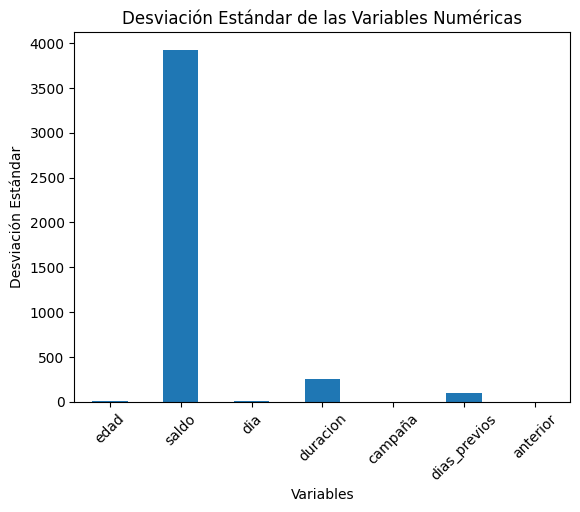

In [130]:
# Crear una gráfica de barras para representar las desviaciones estándar
desviaciones_estandar.plot(kind = 'bar')
plt.title('Desviación Estándar de las Variables Numéricas')
plt.xlabel('Variables')
plt.ylabel('Desviación Estándar')
plt.xticks(rotation=45)
plt.show()

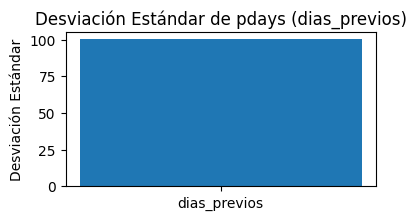

In [131]:
# Graficar la desviación estándar de 'pdays'
plt.figure(figsize=(4, 2))  # Configura el tamaño de la figura
plt.bar('dias_previos', destd_pdays)  # Crea una barra para la desviación estándar de 'pdays'
plt.title('Desviación Estándar de pdays (dias_previos)')
plt.ylabel('Desviación Estándar')
plt.show()

In [132]:
#conteo de valores con -1
count = data['dias_previos'].value_counts()[-1]
print(count)

36953


In [133]:
# Calcula la media del atributo "pdays: dias de contacto al usuario antes de la campaña actual"
media = data['dias_previos'].mean()

print("Promedio de dias de contacto:", media)

Promedio de dias de contacto: 40.17822461123277


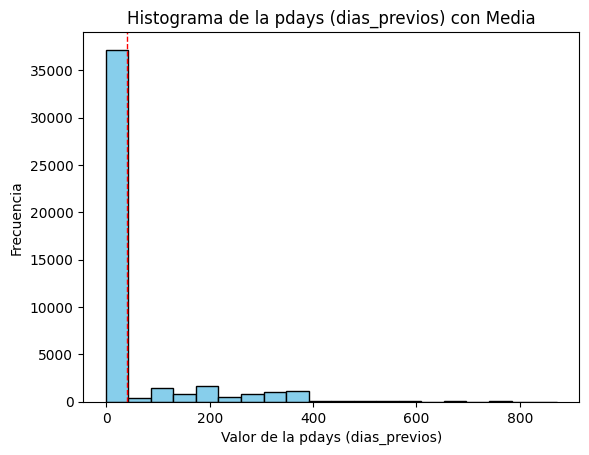

In [134]:
# Graficar un histograma del atributo "pdays"
plt.hist(data['dias_previos'], bins=20, color='skyblue', edgecolor='black')

# Agregar una línea vertical para mostrar la media
plt.axvline(media, color='red', linestyle='dashed', linewidth=1)

# Etiquetas y título
plt.xlabel('Valor de la pdays (dias_previos)')
plt.ylabel('Frecuencia')
plt.title('Histograma de la pdays (dias_previos) con Media')

# Mostrar la gráfica
plt.show()

In [135]:
# Calcula la desviación estándar del atributo "pdays"
desviacion_estandar = data['dias_previos'].std()

print("Desviación estándar de la pdays (dias_previos):", desviacion_estandar)

Desviación estándar de la pdays (dias_previos): 100.10328306134012


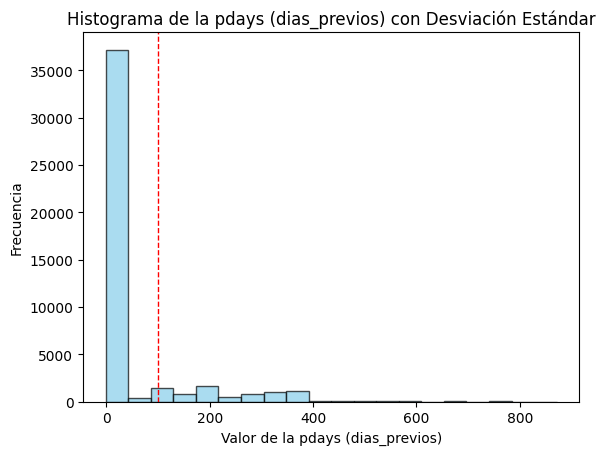

In [136]:
# Graficar un histograma del atributo "campaña"
plt.hist(data['dias_previos'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Agregar una línea vertical para mostrar la desviación estándar
plt.axvline(desviacion_estandar, color='red', linestyle='dashed', linewidth=1)

# Etiquetas y título
plt.xlabel('Valor de la pdays (dias_previos)')
plt.ylabel('Frecuencia')
plt.title('Histograma de la pdays (dias_previos) con Desviación Estándar')

# Mostrar la gráfica
plt.show()


##4.3 Filas repetidas

In [137]:
#Mostramos la cantidad de registros antes de aplicar una transformación, limpieza o filtro
print(f'Tamaño del set antes de eliminar las filas repetidas: {data.shape}')
data.drop_duplicates(inplace=True)


#Mostramos la cantidad de registros después de aplicar una transformación, limpieza o filtro
print(f'Tamaño del set después de eliminar las filas repetidas: {data.shape}')

Tamaño del set antes de eliminar las filas repetidas: (45207, 17)
Tamaño del set después de eliminar las filas repetidas: (45203, 17)


##4.4 *Outliers* en las variables numéricas

No siempre se deben eliminar los *outliers* porque dependiendo de la variable numérica analizada estos pueden contener información importante.

Creemos gráficas tipo "boxplot" de las columnas numéricas:

In [138]:
# Cargo nuevamente los datos para no estar cambiando los nombres de las columnas
data = pd.read_csv('/content/dataset_banco.csv')

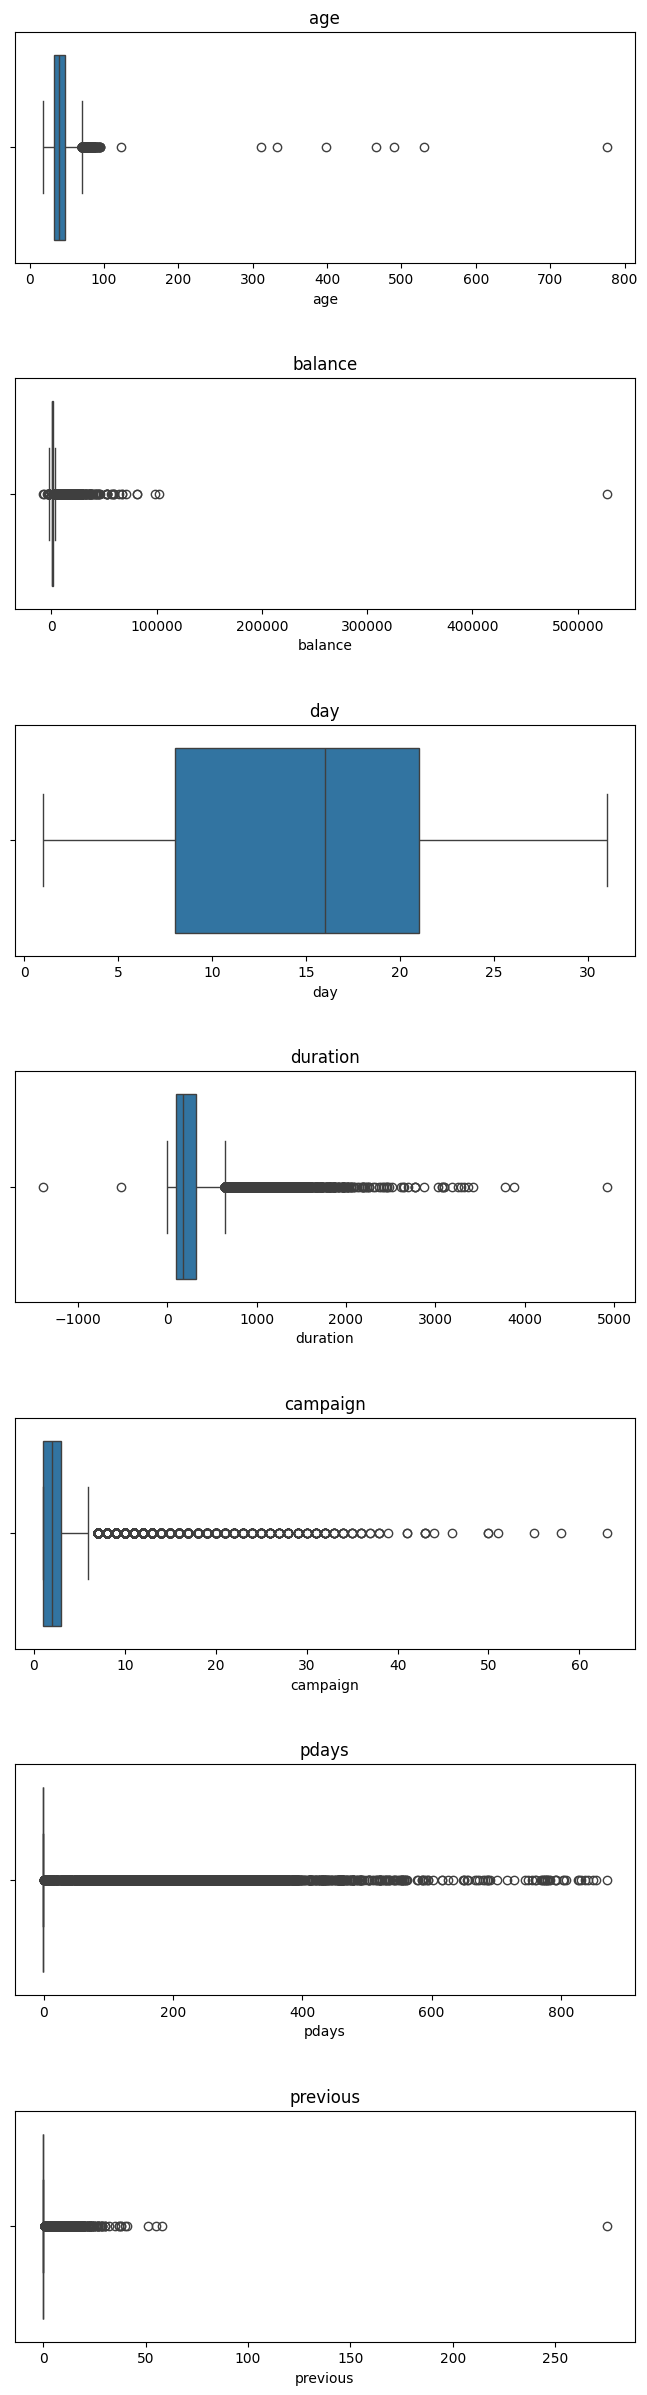

In [139]:
# Generar gráficas individuales pues las variables numéricas
# están en rangos diferentes
cols_num = ['age', 'balance', 'day', 'duration', 'campaign',
            'pdays', 'previous']

fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=0.5)


for i, col in enumerate(cols_num):
    sns.boxplot(x=col, data=data, ax=ax[i])
    ax[i].set_title(col)

**Observaciones:**
- "age": hay sujetos con edades mucho mayores a 100 años
- "duration": hay valores negativos
- "previous": hay un valor extremadamente alto (cercano a 300)

In [140]:
# Eliminar filas con "age">100
print(f'Tamaño del set antes de eliminar registros de edad: {data.shape}')

data = data.drop(data[data['age'] > 100].index)


print(f'Tamaño del set después de eliminar registros de edad: {data.shape}')

Tamaño del set antes de eliminar registros de edad: (45215, 17)
Tamaño del set después de eliminar registros de edad: (45207, 17)


In [141]:
# Eliminar filas con "duration"<0
print(f'Tamaño del set antes de eliminar registros de duración: {data.shape}')
data = data.drop(data[data['duration'] < 0].index)
#data = data[data['duration']>0]
print(f'Tamaño del set después de eliminar registros de duración: {data.shape}')

Tamaño del set antes de eliminar registros de duración: (45207, 17)
Tamaño del set después de eliminar registros de duración: (45205, 17)


In [142]:
# Eliminar filas con "previous">100
print(f'Tamaño del set antes de eliminar registros de previous: {data.shape}')
data = data.drop(data[data['previous'] > 100].index)
#data = data[data['previous']<=100]
print(f'Tamaño del set después de eliminar registros de previous: {data.shape}')

Tamaño del set antes de eliminar registros de previous: (45205, 17)
Tamaño del set después de eliminar registros de previous: (45204, 17)


##4.5 Errores tipográficos en variables categóricas

En una variable categórica pueden aparecer sub-niveles como "unknown" y "UNK" que para nosotros son equivalentes pero que para nuestro programa parecerían diferentes.

Se deben unificar estos sub-niveles

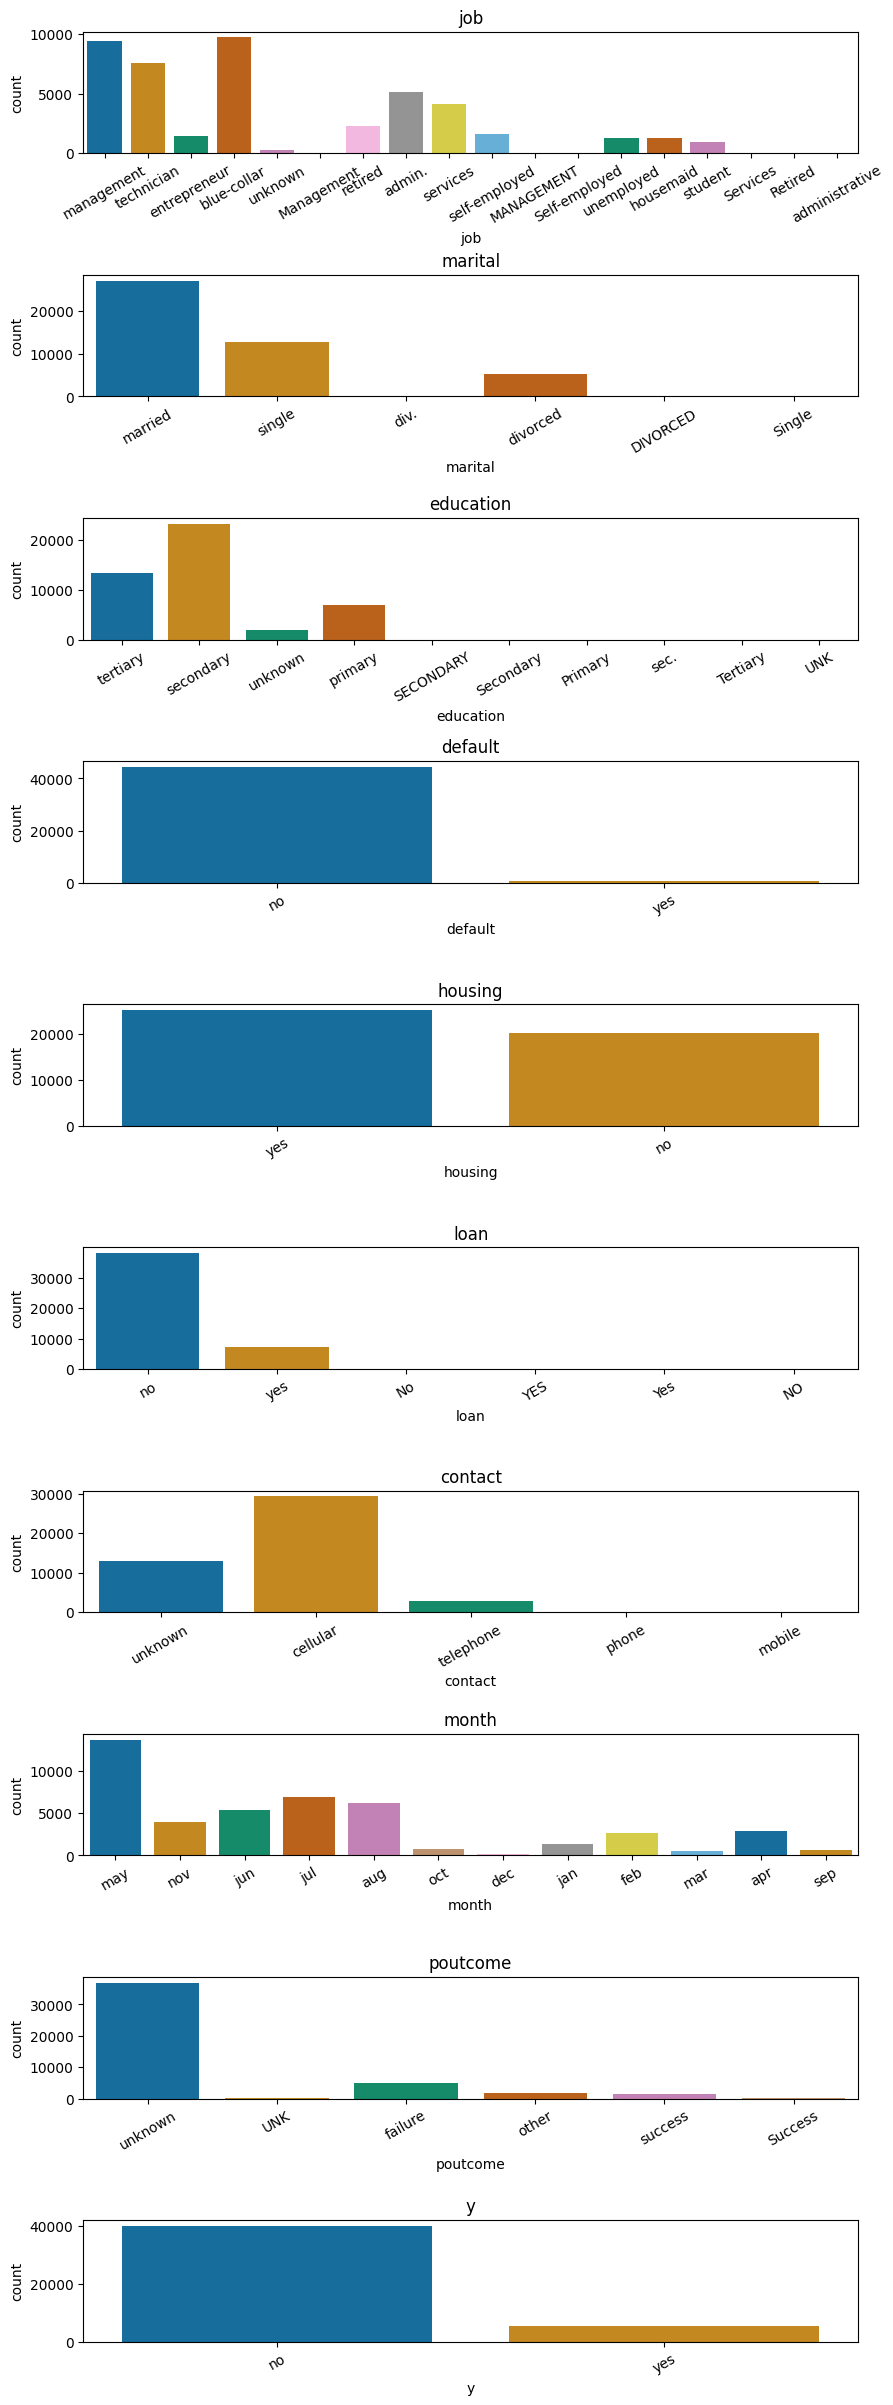

In [143]:
# Graficar los subniveles de cada variable categórica
cols_cat = ['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'y']

fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
  sns.countplot(x=col, hue=col, data=data, ax=ax[i], palette= 'colorblind', legend=False)
  ax[i].set_title(col)
  ax[i].tick_params(axis='x', labelrotation=30)

Inicialmente se observa que hay sub-niveles con el mismo nombre pero escritos en minúscula, en mayúscula o con la primera letra en mayúscula.

Unifiquemos estos sub-niveles inicialmente:

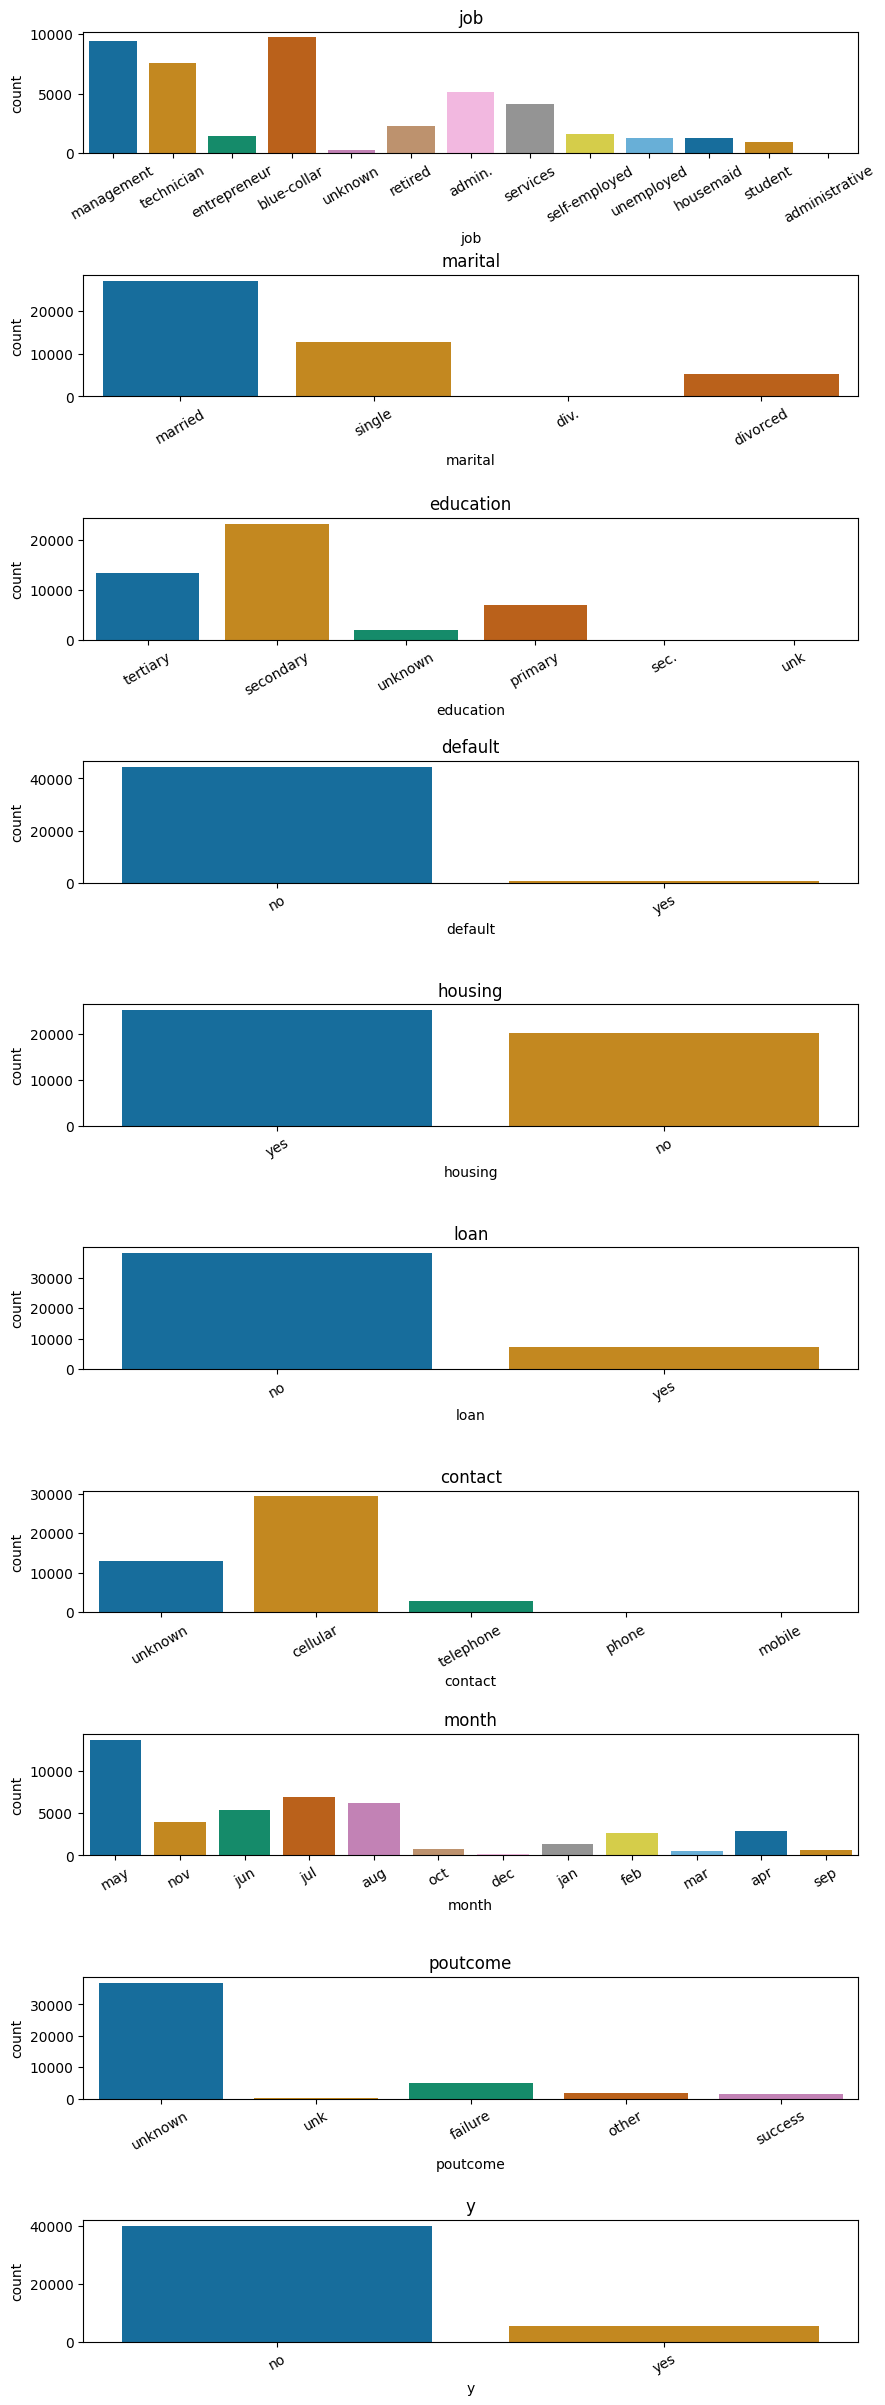

In [144]:
for column in data.columns:
    # Representar en minúsculas sólo si la columna es categórica
    if column in cols_cat:
        data[column] = data[column].str.lower()

# Y generemos las gráficas nuevamente
fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
  sns.countplot(x=col, hue=col, data=data, ax=ax[i], palette='colorblind', legend=False)
  ax[i].set_title(col)
  ax[i].tick_params(axis='x', labelrotation=30)

In [145]:
# job: unificar admin. y administrative
print(f'imprimo valores antes de aplicar el cambio',data['job'].unique()) #Imprimo antes de aplicar el cambio


data['job'] = data['job'].str.replace('admin.','administrative', regex=False) #aplico el cambio (transf, clean, add)


print(f'imprimo valores despues de aplicar el cambio',data['job'].unique()) #Imprimo despues de aplicar el cambio

imprimo valores antes de aplicar el cambio ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student' 'administrative' nan]
imprimo valores despues de aplicar el cambio ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'administrative' 'services' 'self-employed' 'unemployed'
 'housemaid' 'student' nan]


In [146]:
# marital: unificar div. y divorced
print(data['marital'].unique())
data['marital'] = data['marital'].str.replace('div.','divorced', regex=False)
print(data['marital'].unique())

['married' 'single' 'div.' 'divorced' nan]
['married' 'single' 'divorced' nan]


In [147]:
# education: unificar sec. y secondary, unk y unknown
print(data['education'].unique())
data['education'] = data['education'].str.replace('sec.','secondary', regex=False)

data.loc[data['education']=='unk','education'] = 'unknown'
print(data['education'].unique())

['tertiary' 'secondary' 'unknown' 'primary' 'sec.' 'unk' nan]
['tertiary' 'secondary' 'unknown' 'primary' nan]


In [148]:
# contact: unificar telephone y phone
print(data['contact'].unique())
data.loc[data['contact']=='phone','contact'] = 'telephone'
data.loc[data['contact']=='mobile','contact'] = 'cellular'
print(data['contact'].unique())

['unknown' 'cellular' 'telephone' 'phone' 'mobile']
['unknown' 'cellular' 'telephone']


In [149]:
# poutcome: unificar unk y unknown
print(data['poutcome'].unique())
data.loc[data['poutcome']=='unk','poutcome']='unknown'
print(data['poutcome'].unique())

['unknown' 'unk' 'failure' 'other' 'success']
['unknown' 'failure' 'other' 'success']


In [150]:
data.shape

(45204, 17)

In [151]:
!pip install pygwalker

In [152]:
import pygwalker as pyg

In [153]:
pyg.walk(data)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064ff9b8c610bcGsQNLlx7c2zhwHyo" style="height: auto">\n    <hea…

¡Y listo, ya hemos realizado la limpieza de nuestro set de datos!

Originalmente tenía 45.215 registros y 17 columnas. El dataset resultante tiene 45.204 filas (11 menos) y 17 columnas.

El set de datos ya está listo para el Análisis Exploratorio.

In [ ]:
#ruta = "/content/drive/MyDrive/Colab Notebooks/DA_Talento/data/data_clean/dataset_banco_clean.csv"
#data.to_csv(ruta, index=False)


#Taller
Resuelve las siguientes preguntas de negocio

In [154]:
#Edad(age) promedio(mean) de los clientes interesados en adquirir un certificado de depósito(y)
edad_promedio_interesados = data[data['y'] == 'yes']['age'].mean()
print("1. Edad promedio de los clientes interesados:", edad_promedio_interesados)


1. Edad promedio de los clientes interesados: 41.665658093797276


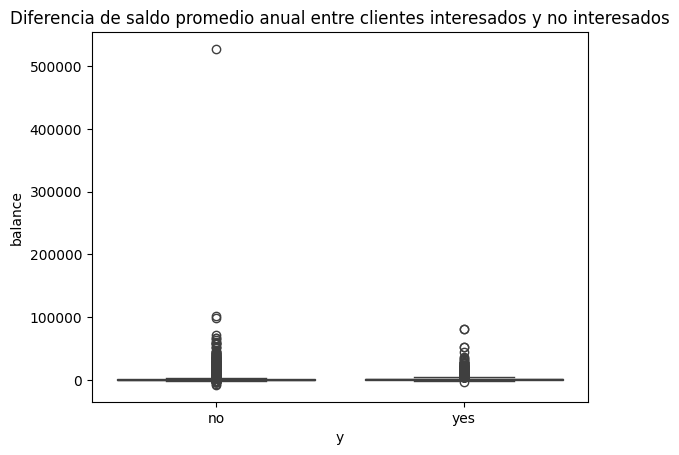

In [155]:
#Diferencia de ingresos entre clientes interesados y no interesados:
sns.boxplot(x='y', y='balance', data=data)
plt.title('Diferencia de saldo promedio anual entre clientes interesados y no interesados')
plt.show()


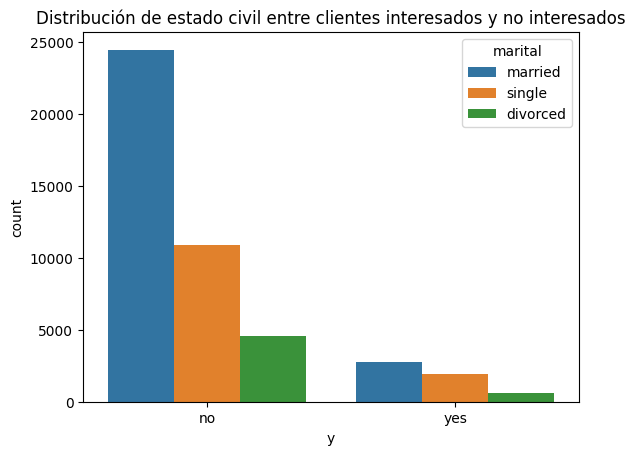

In [156]:
#Distribución de estado civil entre clientes interesados:
sns.countplot(x='y', hue='marital', data=data)
plt.title('Distribución de estado civil entre clientes interesados y no interesados')
plt.show()


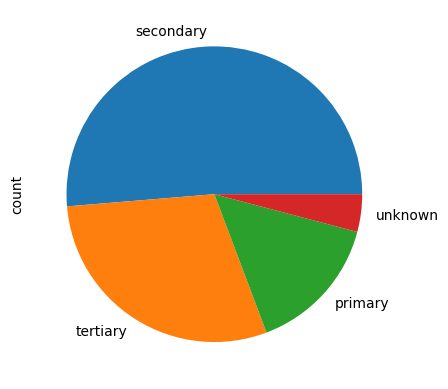

In [157]:
#Grafico de torta o circular para representar el nivel de educación de los encuestados
data.education.value_counts().plot.pie()
plt.show()

In [158]:
data.education.describe()

,education
count,45203
unique,4
top,secondary
freq,23196


In [159]:
contar_educacion = data.education.value_counts()
print(contar_educacion)

education
secondary    23196
tertiary     13301
primary       6849
unknown       1857
Name: count, dtype: int64


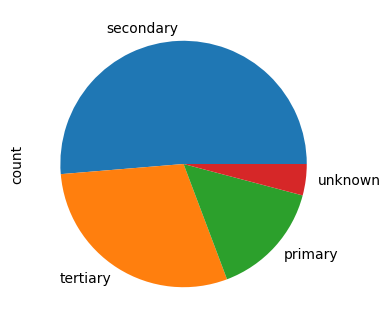

In [160]:
plot2 = contar_educacion.plot.pie(subplots=True, figsize=(9, 4))

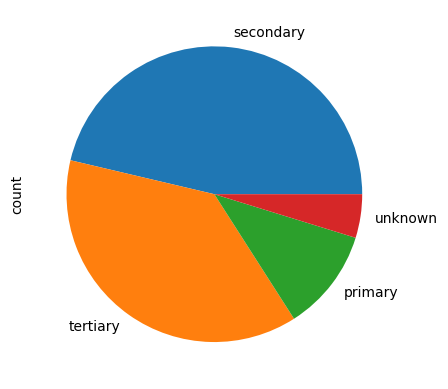

In [161]:
#Grafique el nivel de educación de los interesados en el producto banco
level_education = data[data['y'] == 'yes'].education.value_counts().plot.pie()

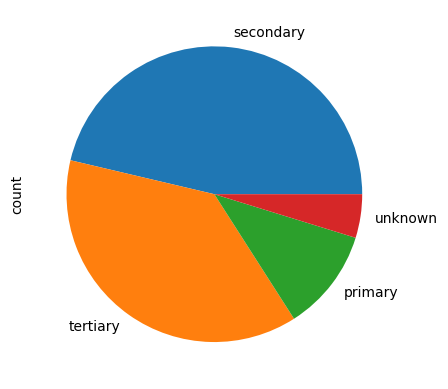

In [162]:
plot2 = data[data['y'] == 'yes'].education.value_counts().plot.pie(subplots=True)

In [ ]:
#para crear un subplot sobre una variable de tipo numerico, debo tener en esa variable
#otras caracteristicas
#ejemplo: education tiene 4 subniveles, y a su vez estos subniveles tengan valores por caracteristicas
#education: level->primary ->cant:1500
#education: secundary->primary ->cant:1500
#education: tertiary->primary ->cant:1500

           level  cant
Primary        5  2439
Secundary     10  4325
Tertiary      20   563


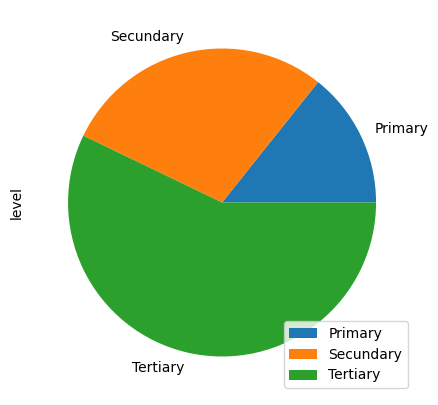

In [163]:
import pandas as pd
data_education = pd.DataFrame({'level': [5, 10, 20],
                            'cant': [2439, 4325, 563]},
                   index=['Primary', 'Secundary', 'Tertiary'])
plot = data_education.plot.pie(y='level', figsize=(5, 5))
print(data_education)

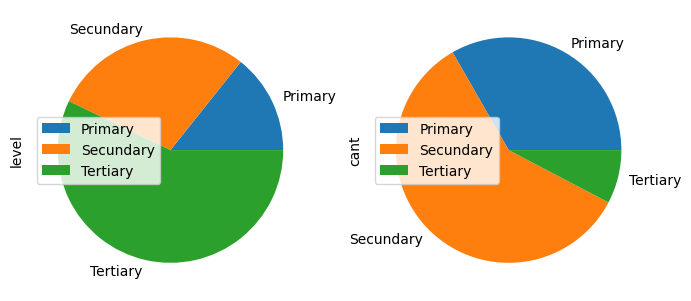

In [164]:
plot = data_education.plot.pie(subplots=True, figsize=(8, 10))

         mass  radius
Mercury  0.33  2439.7
Venus    4.87  6051.8
Earth    5.97  6378.1


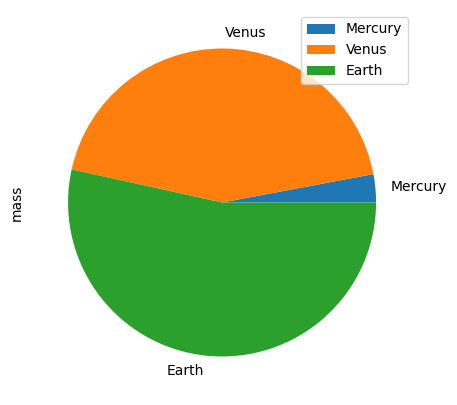

In [165]:
data = pd.DataFrame({'mass': [0.330, 4.87 , 5.97],
                   'radius': [2439.7, 6051.8, 6378.1]},
                   index=['Mercury', 'Venus', 'Earth'])
plot = data.plot.pie(y='mass', figsize=(5, 5))
print(data)

In [167]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, Mercury to Earth
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mass    3 non-null      float64
 1   radius  3 non-null      float64
dtypes: float64(2)
memory usage: 180.0+ bytes


In [172]:
data = pd.read_csv('/content/dataset_banco.csv')

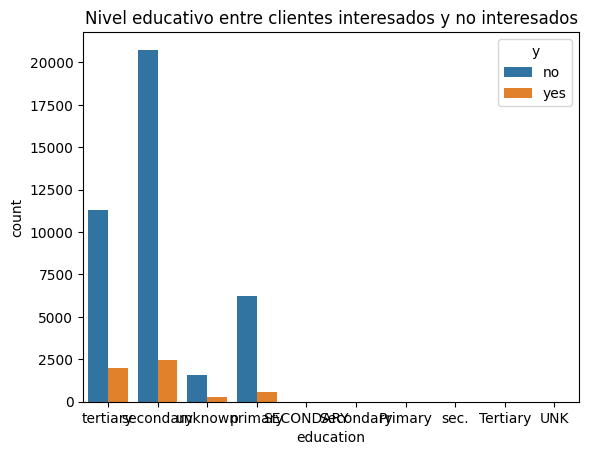

In [173]:
#Nivel educativo predominante entre clientes interesados:
sns.countplot(x='education', hue='y', data=data)
plt.title('Nivel educativo entre clientes interesados y no interesados')
plt.show()

In [174]:
#Proporción de clientes con hipotecas pendientes interesados en el producto:
proporcion_hipoteca_interesados = data[(data['housing'] == 'yes') & (data['y'] == 'yes')].shape[0] / data[data['housing'] == 'yes'].shape[0]
print("5. Proporción de clientes con hipotecas pendientes interesados:", proporcion_hipoteca_interesados)
plt.show()


5. Proporción de clientes con hipotecas pendientes interesados: 0.07703326436415725


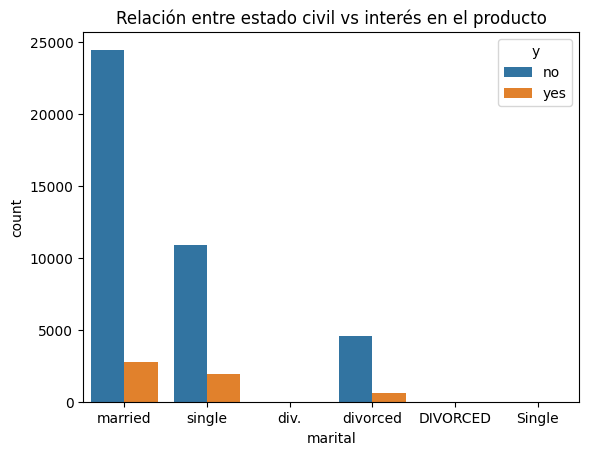

In [175]:
#Relación entre estado civil vs interés en adquirir el certificado de depósito:
sns.countplot(x='marital', hue='y', data=data)
plt.title('Relación entre estado civil vs interés en el producto')
plt.show()

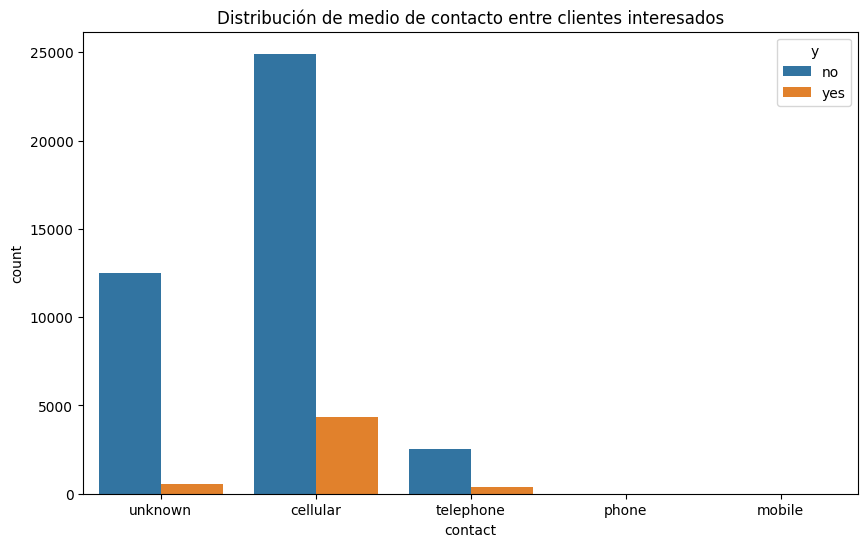

In [176]:
#Distribución medio de contacto de los clientes interesados:
plt.figure(figsize=(10, 6))
sns.countplot(x='contact', hue='y', data=data)
plt.title('Distribución de medio de contacto entre clientes interesados')
plt.show()


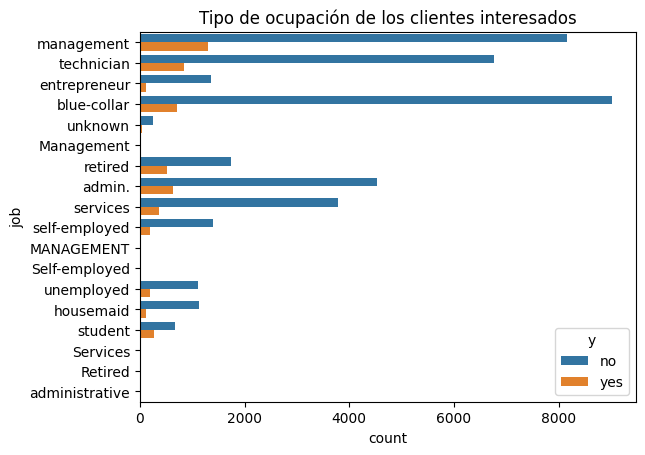

In [177]:
#Tipo de ocupación de los clientes interesados:
sns.countplot(y='job', hue='y', data=data)
plt.title('Tipo de ocupación de los clientes interesados')
plt.show()

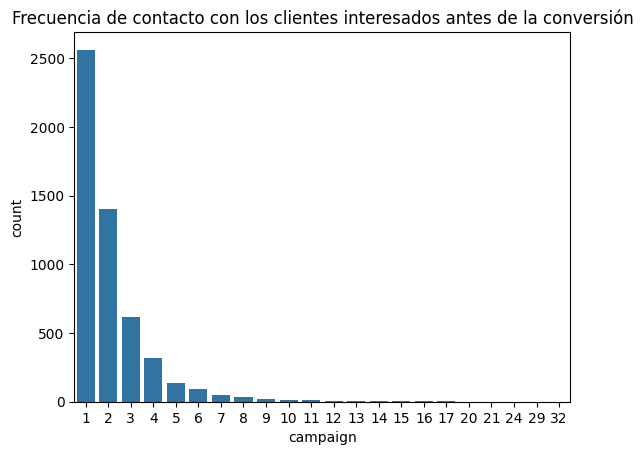

In [178]:
#Frecuencia de contacto con los clientes interesados antes de la conversión:
sns.countplot(x='campaign', data=data[data['y'] == 'yes'])
plt.title('Frecuencia de contacto con los clientes interesados antes de la conversión')
plt.show()

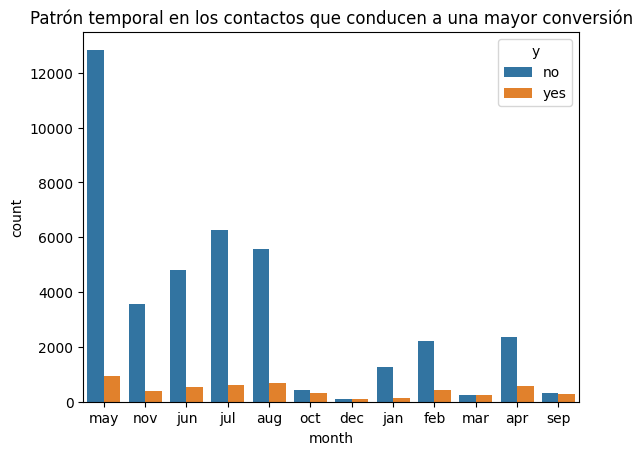

In [179]:
#Patrón temporal en los contactos que conducen a una mayor conversión de clientes:
sns.countplot(x='month', hue='y', data=data)
plt.title('Patrón temporal en los contactos que conducen a una mayor conversión')
plt.show()


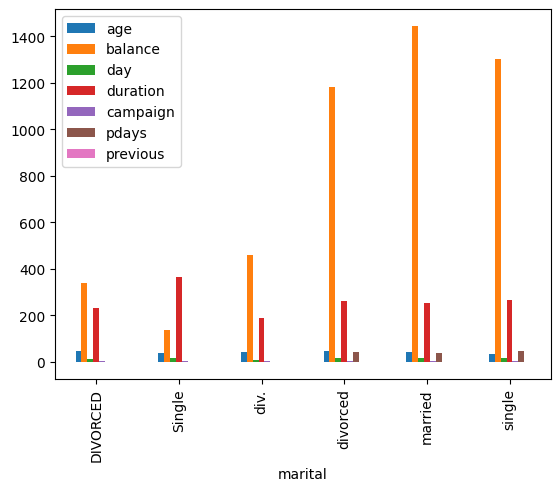

In [187]:
data.groupby('marital').mean(numeric_only=True).plot.bar()
plt.show()